# Time Series Forecasting for Beginners

This notebook walks through a complete, beginner-friendly time series workflow:

 - build a sample dataset
 - create lag features
 - predict the next value with a regression model
 - evaluate the forecast with MAE, RMSE, and MAPE
 - classify whether the series goes up or down next and show a confusion matrix

Confusion matrices are for classification, so the notebook uses a direction-prediction task for that part.

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(42)


def make_supervised_frame(frame, target_col="value", lags=7, include_direction=False):
    supervised = frame.copy()

    for lag in range(1, lags + 1):
        supervised[f"lag_{lag}"] = supervised[target_col].shift(lag)

    supervised["rolling_mean_3"] = supervised[target_col].shift(1).rolling(3).mean()
    supervised["rolling_std_7"] = supervised[target_col].shift(1).rolling(7).std()

    if include_direction:
        supervised["direction"] = (supervised[target_col].shift(-1) > supervised[target_col]).astype(float)
        supervised.loc[supervised.index[-1], "direction"] = np.nan

    return supervised.dropna().reset_index(drop=True)

## 1. Create a Sample Time Series

To keep this notebook self-contained, we generate a realistic synthetic series with trend, seasonality, and noise.

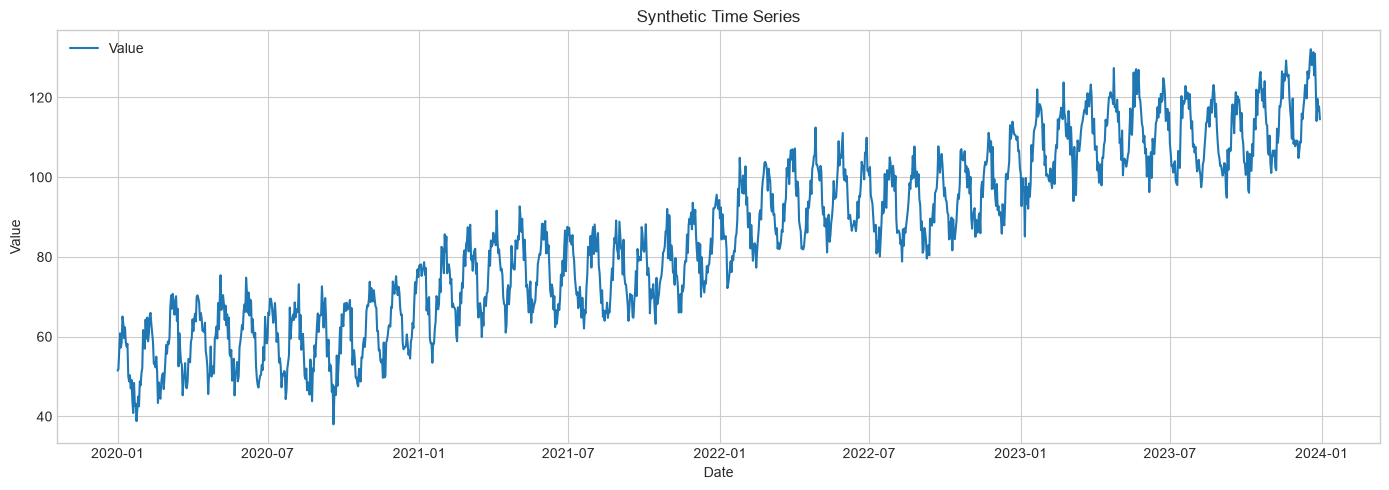

In [34]:
periods = 365 * 4
dates = pd.date_range("2020-01-01", periods=periods, freq="D")
time_index = np.arange(periods)

trend = np.linspace(50, 120, periods)
seasonal = 10 * np.sin(2 * np.pi * time_index / 30)
yearly = 5 * np.sin(2 * np.pi * time_index / 365)
noise = np.random.normal(0, 3, periods)

df = pd.DataFrame({"date": dates, "value": trend + seasonal + yearly + noise})
df.head()

plt.figure(figsize=(14, 5))
plt.plot(df["date"], df["value"], label="Value")
plt.title("Synthetic Time Series")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

## 2. Forecast the Next Value

We convert the series into a supervised learning table with lag features, then train a regression model to predict the next value.

MAE: 4.764
RMSE: 6.059
MAPE: 4.123%


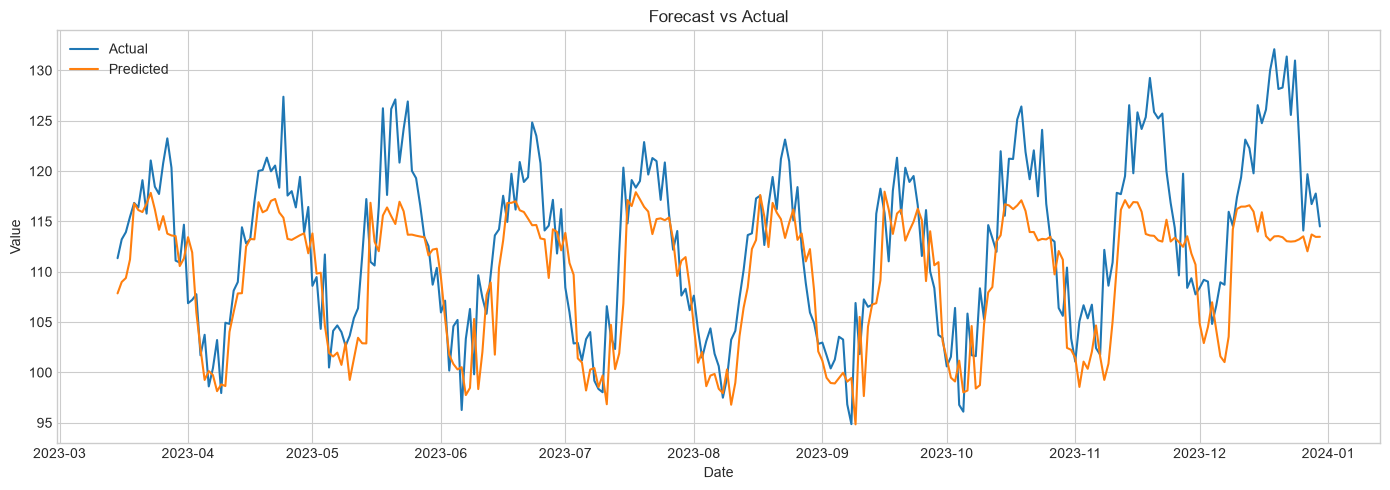

In [35]:
forecast_frame = make_supervised_frame(df, lags=7, include_direction=False)
feature_cols = [c for c in forecast_frame.columns if c.startswith("lag_")] + ["rolling_mean_3", "rolling_std_7"]

split_idx = int(len(forecast_frame) * 0.8)
train_df = forecast_frame.iloc[:split_idx]
test_df = forecast_frame.iloc[split_idx:]

X_train = train_df[feature_cols]
y_train = train_df["value"]
X_test = test_df[feature_cols]
y_test = test_df["value"]

forecast_model = RandomForestRegressor(n_estimators=200, random_state=42)
forecast_model.fit(X_train, y_train)

y_pred = forecast_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAPE: {mape:.3%}")

plt.figure(figsize=(14, 5))
plt.plot(test_df["date"], y_test, label="Actual")
plt.plot(test_df["date"], y_pred, label="Predicted")
plt.title("Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Direction Classification and Confusion Matrix

A confusion matrix is only valid for classification, so here we predict whether the next value will go up or down.

Direction accuracy: 0.557

Classification report:
              precision    recall  f1-score   support

        Down       0.53      0.82      0.64       143
          Up       0.63      0.30      0.41       148

    accuracy                           0.56       291
   macro avg       0.58      0.56      0.53       291
weighted avg       0.58      0.56      0.53       291



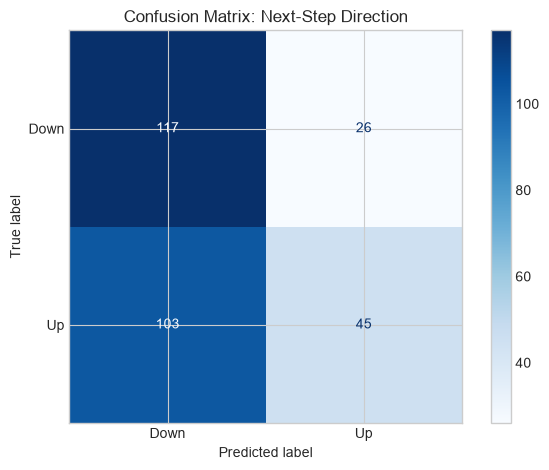

Next value prediction: 113.474
Next direction prediction: Down


In [36]:
direction_frame = make_supervised_frame(df, lags=7, include_direction=True)

split_idx_dir = int(len(direction_frame) * 0.8)
train_dir = direction_frame.iloc[:split_idx_dir]
test_dir = direction_frame.iloc[split_idx_dir:]

X_train_dir = train_dir[feature_cols]
y_train_dir = train_dir["direction"].astype(int)
X_test_dir = test_dir[feature_cols]
y_test_dir = test_dir["direction"].astype(int)

direction_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))
direction_model.fit(X_train_dir, y_train_dir)

direction_pred = direction_model.predict(X_test_dir)
acc_cm = accuracy_score(y_test_dir, direction_pred)
cm = confusion_matrix(y_test_dir, direction_pred)

print(f"Direction accuracy: {acc_cm:.3f}")
print("\nClassification report:")
print(classification_report(y_test_dir, direction_pred, target_names=["Down", "Up"]))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Down", "Up"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix: Next-Step Direction")
plt.tight_layout()
plt.show()

last_features = forecast_frame[feature_cols].iloc[[-1]]
next_value_prediction = forecast_model.predict(last_features)[0]
next_direction_prediction = direction_model.predict(last_features)[0]
next_direction_label = "Up" if next_direction_prediction == 1 else "Down"

print(f"Next value prediction: {next_value_prediction:.3f}")
print(f"Next direction prediction: {next_direction_label}")